# softmax迴歸的從零開始實現
:label:`sec_softmax_scratch`
 
(**就像我們從零開始實現線性迴歸一樣，**)
我們認為softmax迴歸也是重要的基礎，因此(**應該知道實現softmax迴歸的細節**)。
本節我們將使用剛剛在 :numref:`sec_fashion_mnist`中引入的Fashion-MNIST資料集，
並設置資料迭代器的批量大小為256。


In [1]:
import torch
from IPython import display

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
batch_size = 256
import torchvision
from torchvision import transforms
from torch.utils import data

trans = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

train_iter = data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_iter = data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

## 初始化模型參數

和之前線性迴歸的例子一樣，這裡的每個樣本都將用固定長度的向量表示。
原始資料集中的每個樣本都是$28 \times 28$的圖像。
本節[**將展平每個圖像，把它們看作長度為784的向量。**]
在後面的章節中，我們將討論能夠利用圖像空間結構的特徵，
但現在我們暫時只把每個像素位置看作一個特徵。

回想一下，在softmax迴歸中，我們的輸出與類別一樣多。
(**因為我們的資料集有10個類別，所以網路輸出維度為10**)。
因此，權重將構成一個$784 \times 10$的矩陣，
偏置將構成一個$1 \times 10$的行向量。
與線性迴歸一樣，我們將使用常態分布初始化我們的權重`W`，偏置初始化為0。


In [3]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

## 定義softmax操作

在實現softmax迴歸模型之前，我們簡要回顧一下`sum`運算符如何沿著張量中的特定維度工作。
如 :numref:`subseq_lin-alg-reduction`和
 :numref:`subseq_lin-alg-non-reduction`所述，
 [**給定一個矩陣`X`，我們可以對所有元素求和**]（預設情況下）。
也可以只求同一個軸上的元素，即同一列（軸0）或同一行（軸1）。
如果`X`是一個形狀為`(2, 3)`的張量，我們對列進行求和，
則結果將是一個具有形狀`(3,)`的向量。
當調用`sum`運算符時，我們可以指定保持在原始張量的軸數，而不折疊求和的維度。
這將產生一個具有形狀`(1, 3)`的二維張量。


In [4]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

回想一下，[**實現softmax**]由三個步驟組成：
 
1. 對每個項求冪（使用`exp`）；
1. 對每一行求和（小批量中每個樣本是一行），得到每個樣本的規範化常數；
1. 將每一行除以其規範化常數，確保結果的和為1。
 
在查看程式碼之前，我們回顧一下這個表達式：

$$
\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}.
$$

分母或規範化常數，有時也稱為*配分函數*（其對數稱為對數-配分函數）。
該名稱來自[統計物理學](https://en.wikipedia.org/wiki/Partition_function_(statistical_mechanics))中一個模擬粒子群分布的方程。


In [5]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition  # 这里应用了广播机制

如上述程式碼所示，對於任何隨機輸入，[**我們將每個元素變成一個非負數。
此外，依據機率原理，每列總和為1**]。


In [6]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.5835, 0.0593, 0.0129, 0.1502, 0.1941],
         [0.4862, 0.0817, 0.2830, 0.0448, 0.1043]]),
 tensor([1.0000, 1.0000]))

注意，雖然這在數學上看起來是正確的，但我們在程式碼實現中有點草率。
矩陣中的非常大或非常小的元素可能造成數值上溢或下溢，但我們沒有採取措施來防止這點。

## 定義模型

定義softmax操作後，我們可以[**實現softmax回歸模型**]。
下面的程式碼定義了輸入如何通過網路映射到輸出。
注意，將資料傳遞到模型之前，我們使用`reshape`函數將每張原始圖像展平為向量。


In [7]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

## 定義損失函數

接下來，我們實現 :numref:`sec_softmax`中引入的交叉熵損失函數。
這可能是深度學習中最常見的損失函數，因為目前分類問題的數量遠遠超過迴歸問題的數量。

回顧一下，交叉熵採用真實標籤的預測概率的負對數似然。
這裡我們不使用Python的for循環迭代預測（這往往是低效的），
而是通過一個運算符選擇所有元素。
下面，我們[**創建一個資料樣本`y_hat`，其中包含2個樣本在3個類別的預測概率，
以及它們對應的標籤`y`。**]
有了`y`，我們知道在第一個樣本中，第一類是正確的預測；
而在第二個樣本中，第三類是正確的預測。
然後(**使用`y`作為`y_hat`中概率的索引**)，
我們選擇第一個樣本中第一類的概率和第二個樣本中第三類的概率。


In [8]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

現在我們只需一行程式碼就可以[**實現交叉熵損失函數**]。


In [9]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

## 分類精度

給定預測概率分布`y_hat`，當我們必須輸出硬預測（hard prediction）時，
我們通常選擇預測概率最高的類。
許多應用都要求我們做出選擇。如Gmail必須將電子郵件分類為“Primary（主要郵件）”、
“Social（社交郵件）”“Updates（更新郵件）”或“Forums（論壇郵件）”。
Gmail做分類時可能在內部估計概率，但最終它必須在類中選擇一個。

當預測與標籤分類`y`一致時，即是正確的。
分類精度即正確預測數量與總預測數量之比。
雖然直接優化精度可能很困難（因為精度的計算不可導），
但精度通常是我們最關心的性能衡量標準，我們在訓練分類器時幾乎總會關注它。

為了計算精度，我們執行以下操作。
首先，如果`y_hat`是矩陣，那麼假定第二個維度儲存每個類的預測分數。
我們使用`argmax`獲得每行中最大元素的索引來獲得預測類別。
然後我們[**將預測類別與真實`y`元素進行比較**]。
由於等式運算符“`==`”對數據類型很敏感，
因此我們將`y_hat`的數據類型轉換為與`y`的數據類型一致。
結果是一個包含0（錯）和1（對）的張量。
最後，我們求和會得到正確預測的數量。


In [10]:
def accuracy(y_hat, y):  #@save
    """計算預測正確的數量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

我們將繼續使用之前定義的變量`y_hat`和`y`分別作為預測的概率分布和標籤。
可以看到，第一個樣本的預測類別是2（該行的最大元素為0.6，索引為2），
與實際標籤0不一致。
第二個樣本的預測類別是2（該行的最大元素為0.5，索引為2），
與實際標籤2一致。
因此，這兩個樣本的預測精度率為0.5。


In [11]:
accuracy(y_hat, y) / len(y)

0.5

同樣，對於任意數據迭代器`data_iter`可訪問的資料集，
[**我們可以評估在任意模型`net`的精度**]。


In [12]:
def evaluate_accuracy(net, data_iter):  #@save
    """計算在指定資料集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 將模型設置為評估模式
    metric = Accumulator(2)  # 正確預測數、預測總數
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

這裡定義一個實用程序類`Accumulator`，用於對多個變量進行累加。
在上面的`evaluate_accuracy`函數中，
我們在(**`Accumulator`實例中創建了2個變量，
分別用於儲存正確預測的數量和預測的總數**)。
當我們遍歷資料集時，兩者都將隨著時間的推移而累加。


In [13]:
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

由於我們使用隨機權重初始化`net`模型，
因此該模型的精度應接近於隨機猜測。
例如在有10個類別情況下的精度為0.1。


In [14]:
evaluate_accuracy(net, test_iter)

0.082

## 訓練

在我們看過 :numref:`sec_linear_scratch`中的線性回歸實現，
[**softmax回歸的訓練**]過程程式碼應該看起來非常眼熟。
在這裡，我們重構訓練過程的實現以使其可重複使用。
首先，我們定義一個函數來訓練一個迭代週期。
請注意，`updater`是更新模型參數的常用函數，它接受批量大小作為參數。
它可以是`d2l.sgd`函數，也可以是框架的內置優化函數。


In [15]:
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """訓練模型一個迭代週期（定義見第3章）"""
    # 將模型設置為訓練模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 訓練損失總和、訓練準確度總和、樣本數
    metric = Accumulator(3)
    for X, y in train_iter:
        # 計算梯度並更新參數
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch內置的優化器和損失函數
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的優化器和損失函數
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回訓練損失和訓練精度
    return metric[0] / metric[2], metric[1] / metric[2]

在展示訓練函數的實現之前，我們[**定義一個在動畫中繪製資料的實用程序類**]`Animator`，
它能夠簡化本書其餘部分的程式碼。


In [16]:
import matplotlib.pyplot as plt
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """設置matplotlib的軸"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim:
        axes.set_xlim(xlim)
    if ylim:
        axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
class Animator:  #@save
    """在動畫中繪製資料"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地繪製多條線
        if legend is None:
            legend = []
        plt.rcParams['figure.figsize'] = (3.5, 2.5) 
        plt.rcParams['savefig.dpi'] = 144 
        plt.rcParams['figure.dpi'] = 144 
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函數捕獲參數
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向圖表中添加多個資料點
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

接下來我們實現一個[**訓練函數**]，
它會在`train_iter`訪問到的訓練資料集上訓練一個模型`net`。
該訓練函數將會運行多個迭代週期（由`num_epochs`指定）。
在每個迭代週期結束時，利用`test_iter`訪問到的測試資料集對模型進行評估。
我們將利用`Animator`類來可視化訓練進度。


In [17]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """訓練模型（定義見第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

作為一個從零開始的實現，我們使用 :numref:`sec_linear_scratch`中定義的
[**小批量隨機梯度下降來優化模型的損失函數**]，設置學習率為0.1。


In [18]:
lr = 0.1
def sgd(params, lr, batch_size):
    """實現小批量隨機梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()
def updater(batch_size):
    return sgd([W, b], lr, batch_size)

現在，我們[**訓練模型10個迭代週期**]。
請注意，迭代週期（`num_epochs`）和學習率（`lr`）都是可調節的超參數。
通過更改它們的值，我們可以提高模型的分類精度。


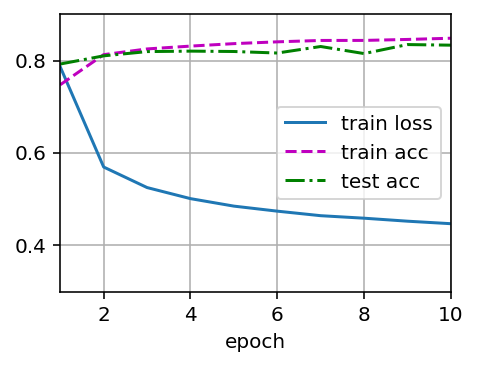

In [19]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

## 預測
 
現在訓練已經完成，我們的模型已經準備好[**對圖像進行分類預測**]。
－給定一系列圖像，我們將比較它們的實際標籤（文本輸出的第一行）和模型預測（文本輸出的第二行）。


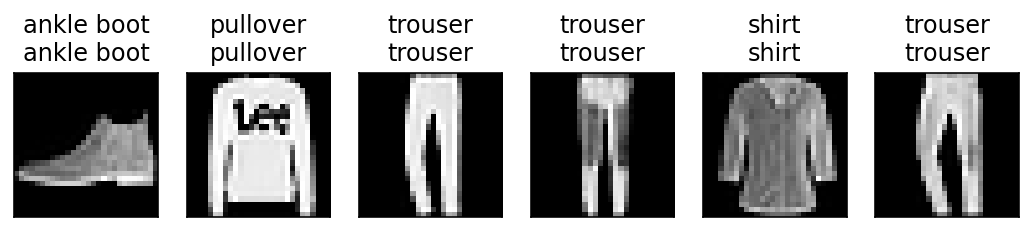

In [20]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST數據集的文本標籤"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(images, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img.numpy(), cmap='gray')
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    plt.show()

def predict_ch3(net, test_iter, n=6):  #@save
    """預測標籤（定義見第3章）"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

## 小結

* 借助softmax回歸，我們可以訓練多分類的模型。
* 訓練softmax回歸循環模型與訓練線性回歸模型非常相似：先讀取資料，再定義模型和損失函數，然後使用優化算法訓練模型。大多數常見的深度學習模型都有類似的訓練過程。

## 練習

1. 本節直接實現了基於數學定義softmax運算的`softmax`函數。這可能會導致什麼問題？提示：嘗試計算$\exp(50)$的大小。

    Ans:
    當輸入值很大時(如50)會導致exp(50)計算結果溢出
    print(torch.exp(torch.tensor(50.0)))  # tensor(5.1847e+21)
    print(torch.exp(torch.tensor(100.0))) # tensor(inf)

    當輸入為大量負值時也可能導致下溢出為0
    print(torch.exp(torch.tensor(-100.0))) # tensor(3.7835e-44)

2. 本節中的函數`cross_entropy`是根據交叉熵損失函數的定義實現的。它可能會有什麼問題？提示：考慮對數的定義域。

    Ans:
    當預測概率為0時,log(0)會得到-inf,導致數值不穩定
    y_hat = torch.tensor([0.0])  
    print(torch.log(y_hat)) # tensor(-inf)

3. 請想一個解決方案來解決上述兩個問題。

    Ans:
    def stable_softmax(X):
        # 先減去最大值再計算exp,避免溢出
        X_max = torch.max(X, dim=1, keepdim=True)[0]
        X_exp = torch.exp(X - X_max)
        partition = X_exp.sum(dim=1, keepdim=True)
        return X_exp / partition

    def stable_cross_entropy(y_hat, y):
        # 加入小量epsilon避免log(0)
        epsilon = 1e-6
        return -torch.log(y_hat[range(len(y_hat)), y] + epsilon)

4. 返回概率最大的分類標籤總是最優解嗎？例如，醫療診斷場景下可以這樣做嗎？

    Ans:不一定。
    需要考慮錯誤診斷的代價(漏診vs誤診)
    應該輸出完整的概率分布,而不是簡單取最大值
    可以設定閾值,只有超過某個置信度才給出診斷
    可能需要多個專家確認

5. 假設我們使用softmax回歸來預測下一個單詞，可選取的單詞數目過多可能會帶來哪些問題?

    Ans:詞表過大帶來的問題:
    計算開銷大,softmax要計算所有詞的概率
    記憶體消耗大,權重矩陣維度與詞表大小成正比
    稀疏性問題,大多數詞很少出現
    訓練速度慢,需要更多數據和時間
    解決方法可以包括:
    使用分層softmax
    採樣技術減少計算
    詞表剪枝
    使用子詞單元減小詞表


[Discussions](https://discuss.d2l.ai/t/1789)
